In [1]:
import torch
import torchvision
from torchvision.datasets import MNIST
from IPython.display import display, Image
from torchvision.transforms import transforms

Batch[0]: torch.Size([64, 1, 28, 28]): torch.Size([64])
tensor([[4, 1, 6, 1, 5, 1, 9, 1],
        [3, 3, 0, 2, 5, 7, 1, 9],
        [3, 8, 0, 6, 9, 5, 6, 5],
        [2, 0, 0, 8, 3, 9, 9, 0],
        [7, 8, 8, 0, 2, 2, 3, 2],
        [4, 0, 4, 0, 0, 7, 3, 2],
        [3, 7, 3, 7, 1, 0, 7, 7],
        [6, 1, 7, 6, 1, 2, 9, 4]])


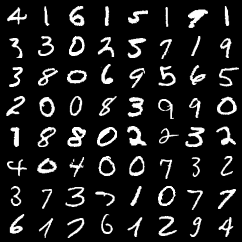

In [15]:
mnist_ds_train = MNIST(root="data/mnist", train=True, transform=transforms.ToTensor(), download=True)
mnist_ds_val = MNIST(root="data/mnist", train=False, transform=transforms.ToTensor(), download=True)
mnist_train_dl = torch.utils.data.DataLoader(mnist_ds_train, batch_size=64, shuffle=True)
mnist_val_dl = torch.utils.data.DataLoader(mnist_ds_val, batch_size=64, shuffle=True)

for b_idx, (b_images, b_nums) in enumerate(mnist_train_dl):
    print(f"Batch[{b_idx}]: {b_images.shape}: {b_nums.shape}")
    print(b_nums.view((-1, 8)))
    display(transforms.ToPILImage()(torchvision.utils.make_grid(b_images)))
    break

In [28]:
class MyMnistFC(torch.nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer1 = torch.nn.Linear(in_features=28*28, out_features=512)
        self.layer2 = torch.nn.Linear(in_features=512, out_features=128)
        self.layer3 = torch.nn.Linear(in_features=128, out_features=10)
    
    def forward(self, x):
        x = torch.nn.Flatten()(x)
        x = self.layer1(x)
        x = torch.nn.ReLU()(x)
        x = self.layer2(x)
        x = torch.nn.ReLU()(x)
        x = self.layer3(x)
        return x

In [29]:
# Train 
model = MyMnistFC()
criteria = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

def validate():
    correct = 0
    total = 0
    with torch.no_grad():
        for b_idx, (b_images, b_nums) in enumerate(mnist_val_dl):
            pred_nums_logits = model(b_images)
            pred_nums = torch.argmax(pred_nums_logits, dim=1)
            total += b_images.shape[0]
            correct += (b_nums == pred_nums).sum()
        print(f"Validation: Correct={correct}/{total} ({correct * 100 / total : .3f}%)")


validate()
for epoch in range(10):
    for b_idx, (b_images, b_nums) in enumerate(mnist_train_dl):
        optimizer.zero_grad()
        num_pred_logits = model(b_images)
        loss = criteria(num_pred_logits, b_nums)
        # if b_idx % 100 == 0:
        #     print(f"Epoch-{epoch}, Batch-{b_idx:3}, Loss: {loss.item()}")
        loss.backward()
        optimizer.step()
    validate()


Validation: Correct=1139/10000 ( 11.390%)
Validation: Correct=9583/10000 ( 95.830%)
Validation: Correct=9712/10000 ( 97.120%)
Validation: Correct=9786/10000 ( 97.860%)
Validation: Correct=9808/10000 ( 98.080%)
Validation: Correct=9791/10000 ( 97.910%)
Validation: Correct=9801/10000 ( 98.010%)
Validation: Correct=9723/10000 ( 97.230%)
Validation: Correct=9806/10000 ( 98.060%)
Validation: Correct=9767/10000 ( 97.670%)
Validation: Correct=9775/10000 ( 97.750%)


GT: tensor([[6, 8, 9, 8, 7, 5, 0, 6],
        [7, 1, 0, 3, 4, 4, 6, 8],
        [0, 2, 2, 8, 9, 9, 3, 4],
        [2, 4, 1, 2, 6, 2, 5, 0],
        [3, 2, 0, 5, 8, 7, 0, 4],
        [2, 5, 2, 2, 0, 5, 1, 2],
        [7, 1, 1, 2, 4, 0, 3, 8],
        [5, 0, 8, 2, 4, 4, 2, 1]])


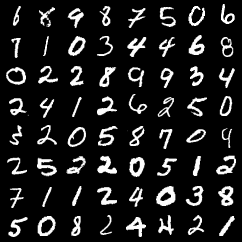

Predicted: tensor([[1, 8, 9, 8, 7, 5, 0, 6],
        [7, 1, 0, 3, 4, 4, 6, 8],
        [0, 2, 2, 8, 9, 9, 3, 4],
        [2, 4, 1, 2, 6, 2, 5, 0],
        [3, 2, 0, 5, 8, 7, 0, 4],
        [2, 5, 2, 2, 0, 5, 1, 2],
        [7, 1, 1, 2, 4, 0, 3, 8],
        [5, 0, 8, 2, 4, 4, 2, 1]])
Wrong: 1/64
torch.Size([1, 1, 1, 28, 28]) tensor([[0]])


In [53]:
for b_idx, (b_images, b_nums) in enumerate(mnist_train_dl):
    pred_nums_logits = model(b_images)
    pred_nums = torch.argmax(pred_nums_logits, dim=1)
    total = b_images.shape[0]
    correct = (b_nums == pred_nums).sum()
    print("GT:", b_nums.view((-1, 8)))
    display(transforms.ToPILImage()(torchvision.utils.make_grid(b_images)))
    print("Predicted:", pred_nums.view((-1, 8)))
    incorrect_idxs = torch.argwhere(pred_nums != b_nums)
    print(f"Wrong: {incorrect_idxs.shape[0]}/{b_images.shape[0]}")
    if incorrect_idxs.shape[0] > 0:
        wrong_images = b_images[incorrect_idxs]
        print(wrong_images.shape, incorrect_idxs)
        display(transforms.ToPILImage()(torchvision.utils.make_grid(wrong_images[0])))
    break

In [71]:
# Quality is not going over 98%, so trying CNNs

class MNistCNNs(torch.nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer1 = torch.nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=2) # [B,1,28,28] => [B,64,13,13]
        self.layer2 = torch.nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2) # [B,64,13,13] => [B,128,6,6]
        self.layer3 = torch.nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2) # [B,128,6,6] => [B,256,2,2]
        self.fc = torch.nn.Linear(in_features=2*2*256, out_features=10)
        self.flatten = torch.nn.Flatten()
        self.relu = torch.nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.fc(self.flatten(x))
        return x

model_cnn = MNistCNNs()
print(model_cnn)
print("Parameter count:", sum([p.numel() for p in model_cnn.parameters()]))

MNistCNNs(
  (layer1): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2))
  (layer2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
  (layer3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2))
  (fc): Linear(in_features=1024, out_features=10, bias=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu): ReLU()
)
Parameter count: 379914


In [75]:
model_cnn = MNistCNNs()
criteria = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model_cnn.parameters(), lr=0.001)

def evaluate():
    total = 0
    correct = 0
    with torch.no_grad():
        for b_idx, (b_images, b_nums) in enumerate(mnist_val_dl):
            y_pred = model_cnn(b_images)
            y_pred_nums = torch.argmax(y_pred, dim=1)
            total += b_images.shape[0]
            correct += (y_pred_nums == b_nums).sum()
    print(f"Validation: Correct={correct}/{total} ({correct*100/total:.2f}%)")

evaluate()
for epoch in range(10):
    for b_idx, (b_images, b_nums) in enumerate(mnist_train_dl):
        optimizer.zero_grad()
        y_pred = model_cnn(b_images)
        loss = criteria(y_pred, b_nums)
        loss.backward()
        optimizer.step()
        # if b_idx % 100 == 0:
        #     print(f"Batch[{b_idx}]: Loss={loss.item()}")
    evaluate()



Validation: Correct=1151/10000 (11.51%)
Validation: Correct=9817/10000 (98.17%)
Validation: Correct=9843/10000 (98.43%)
Validation: Correct=9870/10000 (98.70%)
Validation: Correct=9861/10000 (98.61%)
Validation: Correct=9885/10000 (98.85%)
Validation: Correct=9874/10000 (98.74%)
Validation: Correct=9870/10000 (98.70%)
Validation: Correct=9812/10000 (98.12%)
Validation: Correct=9861/10000 (98.61%)
Validation: Correct=9858/10000 (98.58%)
